# Hypothesis 1: Recursive Sketch improves predictive performance

This notebook compares original features, initial random projection, one-shot tree-path projection, and full Recursive Sketch at the same final dimension. It reports classification accuracy and regression R² over held-out test data.

In [1]:
import matplotlib.pyplot as plt
import warnings
from sklearn.random_projection import DataDimensionalityWarning
warnings.filterwarnings(
    "ignore",
    category=DataDimensionalityWarning,
    message="The number of components is higher than the number of features.*",
)

import sys
from pathlib import Path

notebooks_dir = Path.cwd() / 'notebooks'
if not (notebooks_dir / '_hypothesis_utils.py').exists():
    notebooks_dir = Path.cwd()
sys.path.insert(0, str(notebooks_dir))

import pandas as pd
from _hypothesis_utils import (
    CLASSIFICATION_SEEDS, OneShotTreePathTransformer, classification_data,
    classification_score, downstream_classifier, downstream_regressor,
    forest_classifier, forest_regressor, recursive_sketch, initial_projection,
    regression_data, regression_scores, plot_critical_difference,
)

classification seed=0: p=120, d=20*p=2400


classification seed=1: p=120, d=20*p=2400


,seed,method,accuracy,errors
0,0,original,0.620,167
1,0,initial random projection,0.623,166
2,0,one-shot tree-path,0.814,82
3,0,Recursive Sketch,0.809,84
4,1,original,0.680,141
5,1,initial random projection,0.680,141
6,1,one-shot tree-path,0.836,72
7,1,Recursive Sketch,0.850,66


,mean,std
method,,
Recursive Sketch,0.830,0.029
initial random projection,0.651,0.040
one-shot tree-path,0.825,0.016
original,0.650,0.042


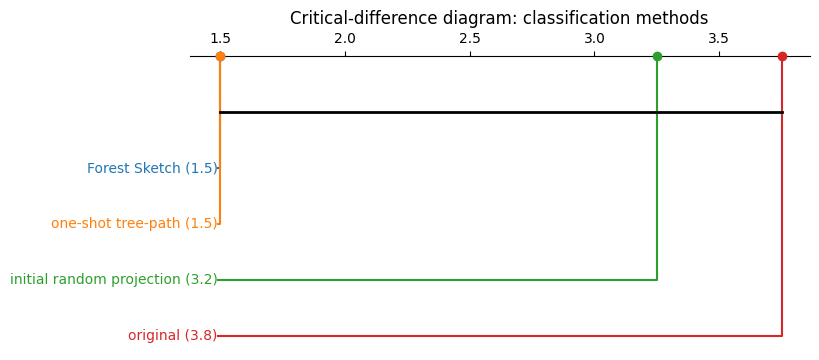

In [2]:
classification_rows = []
for seed in CLASSIFICATION_SEEDS[:2]:
    X_train, _, X_test, y_train, _, y_test = classification_data(seed)
    classification_dimension = 20 * X_train.shape[1]
    print(f'classification seed={seed}: p={X_train.shape[1]}, d=20*p={classification_dimension}')
    X_train_0, X_test_0, _ = initial_projection(X_train, X_test, classification_dimension, seed)
    models = {
        'original': ('array', X_train, X_test),
        'initial random projection': ('array', X_train_0, X_test_0),
        'one-shot tree-path': ('transformer', OneShotTreePathTransformer(forest_classifier(seed, n_estimators=100), classification_dimension, seed), None),
        'Recursive Sketch': ('transformer', recursive_sketch(seed, classification_dimension, 2), None),
    }
    for name, (kind, train_view, test_view) in models.items():
        if kind == 'transformer':
            representation = train_view
            representation.fit(X_train, y_train)
            train_view = representation.transform(X_train)
            test_view = representation.transform(X_test)
        accuracy, errors = classification_score(
            downstream_classifier(seed), train_view, y_train, test_view, y_test
        )
        classification_rows.append({'seed': seed, 'method': name, 'accuracy': accuracy, 'errors': errors})
classification = pd.DataFrame(classification_rows)
display(classification.round(3))
classification_summary = classification.groupby('method').accuracy.agg(['mean', 'std']).round(3)
display(classification_summary)
plot_critical_difference(
    classification,
    block_column='seed',
    method_column='method',
    title='Critical-difference diagram: classification methods',
)
plt.show()

regression seed=0: p=80, d=20*p=1600


regression seed=1: p=80, d=20*p=1600


,seed,method,r2,rmse
0,0,original,0.990,18.380
1,0,initial random projection,0.990,18.382
2,0,one-shot tree-path,0.611,115.829
3,0,Recursive Sketch,0.460,136.509
4,1,original,0.995,18.037
5,1,initial random projection,0.995,18.037
6,1,one-shot tree-path,0.461,184.920
7,1,Recursive Sketch,0.419,192.026


,r2,rmse
method,,
Recursive Sketch,0.439,164.268
initial random projection,0.993,18.210
one-shot tree-path,0.536,150.374
original,0.993,18.208


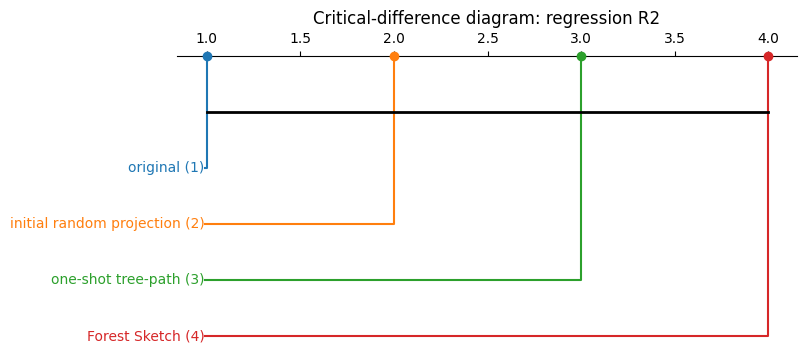

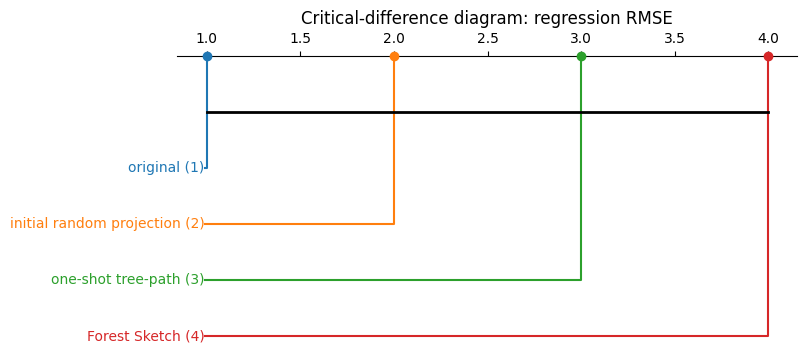

Classification hypothesis: SUPPORTED
Regression hypothesis: NOT SUPPORTED


In [3]:
regression_rows = []
for seed in CLASSIFICATION_SEEDS[:2]:
    X_train, _, X_test, y_train, _, y_test = regression_data(seed)
    regression_dimension = 20 * X_train.shape[1]
    print(f'regression seed={seed}: p={X_train.shape[1]}, d=20*p={regression_dimension}')
    X_train_0, X_test_0, _ = initial_projection(X_train, X_test, regression_dimension, seed)
    for name, train_view, test_view in [
        ('original', X_train, X_test),
        ('initial random projection', X_train_0, X_test_0),
    ]:
        r2, rmse = regression_scores(downstream_regressor(), train_view, y_train, test_view, y_test)
        regression_rows.append({'seed': seed, 'method': name, 'r2': r2, 'rmse': rmse})
    for name, transformer in [
        ('one-shot tree-path', OneShotTreePathTransformer(forest_regressor(seed, n_estimators=100), regression_dimension, seed)),
        ('Recursive Sketch', recursive_sketch(seed, regression_dimension, 2, kind='regressor')),
    ]:
        train_view = transformer.fit_transform(X_train, y_train)
        test_view = transformer.transform(X_test)
        r2, rmse = regression_scores(downstream_regressor(), train_view, y_train, test_view, y_test)
        regression_rows.append({'seed': seed, 'method': name, 'r2': r2, 'rmse': rmse})
regression = pd.DataFrame(regression_rows)
display(regression.round(3))
regression_summary = regression.groupby('method')[['r2', 'rmse']].mean().round(3)
display(regression_summary)
plot_critical_difference(
    regression,
    block_column='seed',
    method_column='method',
    score_column='r2',
    title='Critical-difference diagram: regression R2',
)
plt.show()
plot_critical_difference(
    regression,
    block_column='seed',
    method_column='method',
    score_column='rmse',
    higher_is_better=False,
    title='Critical-difference diagram: regression RMSE',
)
plt.show()
classification_supported = classification_summary.loc['Recursive Sketch', 'mean'] >= classification_summary.loc['original', 'mean']
regression_supported = regression_summary.loc['Recursive Sketch', 'r2'] >= regression_summary.loc['original', 'r2']
print(f'Classification hypothesis: {"SUPPORTED" if classification_supported else "NOT SUPPORTED"}')
print(f'Regression hypothesis: {"SUPPORTED" if regression_supported else "NOT SUPPORTED"}')

## Conclusion

**Hypothesis:** full Recursive Sketch improves held-out predictive performance over original features and an initial random projection at the same target dimension.

**Experiment:** compare original, initial projected, one-shot tree-path, and two-iteration Recursive Sketch representations on difficult classification and noisy regression tasks across two seeds.

**Measure:** classification accuracy and integer error count; regression R² and RMSE; all measures are computed on held-out test data with the downstream model fixed.

**Result:** not supported in this exploratory run for either classification or regression.